# Lab 7 — De volcado de tickets a sistema inteligente de soporte

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pabloos/nlp2026/blob/main/labs/lab7/lab7_tickets_pipeline.ipynb)

> **Sesión de laboratorio**

El DataFrame `df` empieza con 2 columnas y se enriquece en cada sección.
Al final del lab tendrá 9.

| # | Sección | Columnas del df al terminar |
|---|---------|----------------------------|
| — | *Dataset inicial* | `ticket_id` · `texto` |
| 1 | Aumentación sintética | + `es_sintetico` |
| 2 | Etiquetado zero-shot | + `categoria_predicha` |
| 3 | Resumen ejecutivo | *(sin columna nueva — produce `informe_soporte.md`)* |
| 4 | Extracción estructurada | + `producto` · `urgencia` · `nombre_cliente` · `accion_requerida` |
| 5 | Generación de respuestas | + `borrador_respuesta` |

<table style="border-collapse:collapse;width:100%"><thead><tr><th style="padding:6px 12px;text-align:left;border-bottom:2px solid #aaa;font-size:13px">texto</th></tr></thead><tbody><tr><td style="padding:6px 12px;border-bottom:1px solid #e0e0e0;white-space:pre-wrap;max-width:750px;font-size:13px">Mi sesión se cierra automáticamente cada 5 minutos. El tiempo de sesión debería ser de 8 horas según nuestra configuración corporativa. ¿Puede revisar la configuración de nuestro tenant?</td></tr>
<tr><td style="padding:6px 12px;border-bottom:1px solid #e0e0e0;white-space:pre-wrap;max-width:750px;font-size:13px">cambié de departamento y ahora mi usuario no tiene acceso a las carpetas del nuevo equipo. ¿quién puede darme permisos?</td></tr>
<tr><td style="padding:6px 12px;border-bottom:1px solid #e0e0e0;white-space:pre-wrap;max-width:750px;font-size:13px">la cuenta de mi equipo está compartida y alguien cambió la contraseña sin avisarnos. ahora nadie puede entrar</td></tr>
<tr><td style="padding:6px 12px;border-bottom:1px solid #e0e0e0;white-space:pre-wrap;max-width:750px;font-size:13px">no puedo entrar desde hace dos días. el soporte me dijo que estaba resuelto pero sigue igual. este es mi tercer ticket sobre lo mismo.</td></tr>
<tr><td style="padding:6px 12px;border-bottom:1px solid #e0e0e0;white-space:pre-wrap;max-width:750px;font-size:13px">Me dirijo a ustedes para reportar un problema de acceso. Mi cuenta parece estar bloqueada tras varios intentos fallidos, aunque estoy seguro de que la contraseña es correcta. Por favor, necesito asistencia cuanto antes.</td></tr>
<tr><td style="padding:6px 12px;border-bottom:1px solid #e0e0e0;white-space:pre-wrap;max-width:750px;font-size:13px">El sistema de autenticación no me permite entrar. He recibido un código de verificación en dos pasos pero cuando lo introduzco dice que ha expirado. Esto ocurre en menos de 30 segundos desde que llega el SMS.</td></tr>
<tr><td style="padding:6px 12px;border-bottom:1px solid #e0e0e0;white-space:pre-wrap;max-width:750px;font-size:13px">los usuarios de mi organización tienen login pero no pueden ver los datos del último mes. ¿es un problema de acceso a datos o de los datos en sí?</td></tr>
<tr><td style="padding:6px 12px;border-bottom:1px solid #e0e0e0;white-space:pre-wrap;max-width:750px;font-size:13px">Hola, soy el administrador del sistema y necesito transferir la cuenta de propietario a otro usuario. El usuario actual ya no está en la empresa y necesitamos ese acceso.</td></tr></tbody></table>

In [ ]:
#@title Setup — ejecuta una vez, no edites
import requests, pandas as pd, matplotlib.pyplot as plt, json, os
from datetime import date
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── Servidor ──────────────────────────────────────────────────────────────────
OLLAMA_URL = "https://marc-bull-writing-brave.trycloudflare.com"
MODEL      = "llama3.2:3b"
API_KEY    = "lab7-2026"

# ── Colab: descarga assets del repositorio si es necesario ───────────────────
IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ
if IN_COLAB:
    REPO_RAW = "https://raw.githubusercontent.com/pabloos/nlp2026/main/labs/lab7"
    import subprocess
    for _f in ["tickets.csv", "tickets_ground_truth.csv"]:
        subprocess.run(["wget", "-q", "-nc", f"{REPO_RAW}/{_f}"], check=True)
    print("✓ Datos descargados desde el repositorio.")

# ── Llamada base ──────────────────────────────────────────────────────────────
def llamar_modelo(prompt, system=""):
    try:
        r = requests.post(
            f"{OLLAMA_URL}/api/generate",
            json={"model": MODEL, "prompt": prompt, "system": system, "stream": False},
            headers={"X-API-Key": API_KEY},
            timeout=90
        )
        r.raise_for_status()
        return r.json()["response"].strip()
    except requests.exceptions.ConnectionError:
        raise ConnectionError(f"Sin conexion a {OLLAMA_URL}. El servidor esta encendido?")
    except requests.exceptions.Timeout:
        raise TimeoutError("Timeout >90s. El modelo puede estar cargando, espera y reintenta.")
    except requests.exceptions.HTTPError as e:
        raise RuntimeError(f"HTTP {e.response.status_code}: {e.response.text}")

# ── Helpers ───────────────────────────────────────────────────────────────────
def sanear_json(raw):
    """Extrae el JSON aunque el modelo anada texto antes o despues."""
    i, f = raw.find("{"), raw.rfind("}")
    if i == -1 or f <= i:
        raise ValueError(f"Sin JSON en output: {raw!r}"[:80])
    return json.loads(raw[i:f+1])

def diversidad_lexica(textos):
    """Ratio vocabulario unico / total palabras por corpus."""
    todas = [w for t in textos for w in str(t).lower().split()]
    return round(len(set(todas)) / len(todas), 3) if todas else 0

# ── Batch: aumentacion ────────────────────────────────────────────────────────
def run_generacion(df, prompt_fn, objetivo=50):
    """Genera tickets sinteticos hasta llegar a `objetivo` por categoria.
    prompt_fn(categoria, ejemplos) debe devolver (sistema, prompt).
    """
    conteo = df["categoria"].value_counts()
    nuevos, max_id = [], df["ticket_id"].max()
    for cat in ["facturacion", "datos"]:
        cat_real = "facturación" if cat == "facturacion" else cat
        a_generar = max(0, objetivo - conteo.get(cat_real, 0))
        if a_generar == 0:
            print(f"  {cat_real}: ya tiene {conteo.get(cat_real,0)} tickets")
            continue
        ejemplos = df[df["categoria"] == cat_real][["texto"]].to_dict("records")[:2]
        print(f"  Generando {a_generar} tickets de '{cat_real}'...")
        for i in range(a_generar):
            sistema, prompt = prompt_fn(cat_real, ejemplos)
            try:
                raw = llamar_modelo(prompt, system=sistema)
                ini, fin = raw.find("{"), raw.rfind("}")
                texto = json.loads(raw[ini:fin+1])["texto"] if ini != -1 else raw[:300]
            except Exception:
                texto = raw[:300]
            max_id += 1
            nuevos.append({"ticket_id": max_id, "texto": texto,
                           "categoria": cat_real, "es_sintetico": True})
            print(f"    [{i+1}/{a_generar}]", end="\r")
        print(f"    [{a_generar}/{a_generar}] {cat_real} ✓     ")
    if nuevos:
        return pd.concat([df, pd.DataFrame(nuevos)], ignore_index=True)
    return df

# ── Batch: etiquetado ─────────────────────────────────────────────────────────
ETIQUETAS_VALIDAS = ["acceso", "facturación", "rendimiento", "datos", "no_clasificable"]

def run_etiquetado(df, prompt_fn):
    """Annade columna categoria_predicha.
    prompt_fn(texto) debe devolver (sistema, prompt).
    """
    etiquetas = []
    for i, (_, row) in enumerate(df.iterrows()):
        if i % 20 == 0: print(f"  [{i}/{len(df)}]", end="\r")
        sistema, prompt = prompt_fn(row["texto"])
        etiqueta = "no_clasificable"
        for _ in range(2):
            try:
                raw = llamar_modelo(prompt, system=sistema)
                tok = raw.strip().lower().split()
                etiqueta = tok[0].rstrip(".,;") if tok else "no_clasificable"
                if etiqueta not in ETIQUETAS_VALIDAS: etiqueta = "no_clasificable"
                break
            except TimeoutError:
                pass
        etiquetas.append(etiqueta)
    print(f"  [{len(df)}/{len(df)}] ✓")
    df = df.copy()
    df["categoria_predicha"] = etiquetas
    return df

def reveal_accuracy(df):
    """Merge con ground truth, imprime accuracy y muestra matriz de confusion."""
    gt = pd.read_csv("tickets_ground_truth.csv")
    ev = (df[~df["es_sintetico"]]
          .merge(gt[["ticket_id","categoria"]].rename(columns={"categoria":"real"}),
                 on="ticket_id"))
    evf = ev[ev["categoria_predicha"] != "no_clasificable"]
    n_nc = (ev["categoria_predicha"] == "no_clasificable").sum()
    if evf.empty:
        print(f"⚠  Todos los tickets se clasificaron como no_clasificable ({n_nc}/{len(ev)}).")
        print("   Causa mas probable: falta la instruccion de formato en el prompt.")
        print("   Asegurate de descomentar UNA opcion del bloque 'formato de salida'.")
        return ev
    print(f"Accuracy: {accuracy_score(evf['real'], evf['categoria_predicha']):.2%}  "
          f"({n_nc} no_clasificable ignorados)\n")
    orden = ["acceso","facturación","rendimiento","datos"]
    cm = confusion_matrix(evf["real"], evf["categoria_predicha"], labels=orden)
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(4)); ax.set_xticklabels(orden, rotation=30, ha="right")
    ax.set_yticks(range(4)); ax.set_yticklabels(orden)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i,j], ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black")
    plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()
    print(classification_report(evf["real"], evf["categoria_predicha"]))
    return ev

# ── Batch: extraccion ─────────────────────────────────────────────────────────
def run_extraccion(df, prompt_fn):
    """Annade columnas producto, urgencia, nombre_cliente, accion_requerida.
    prompt_fn(texto) debe devolver (sistema, prompt).
    """
    resultados, fallidos = [], []
    for i, (_, row) in enumerate(df.iterrows()):
        if i % 20 == 0: print(f"  [{i}/{len(df)}]", end="\r")
        sistema, prompt = prompt_fn(row["texto"])
        try:
            datos = sanear_json(llamar_modelo(prompt, system=sistema))
            resultados.append({"ticket_id": row["ticket_id"],
                               "producto": datos.get("producto"),
                               "urgencia": datos.get("urgencia"),
                               "nombre_cliente": datos.get("nombre_cliente"),
                               "accion_requerida": datos.get("accion_requerida")})
        except Exception:
            fallidos.append(row["ticket_id"])
            resultados.append({"ticket_id": row["ticket_id"],
                               "producto": None, "urgencia": None,
                               "nombre_cliente": None, "accion_requerida": None})
    print(f"  [{len(df)}/{len(df)}] ✓  Fallidos: {len(fallidos)}")
    if fallidos: print(f"  IDs fallidos: {fallidos[:10]}")
    return df.merge(pd.DataFrame(resultados), on="ticket_id", how="left"), fallidos

# ── Batch: borradores ─────────────────────────────────────────────────────────
def run_borradores(df_urgentes, prompts_dict):
    """Genera borrador_respuesta para cada ticket urgente segun su categoria."""
    fallback = "Eres un agente de soporte tecnico. Respuestas utiles y empaticas."
    borradores = []
    for i, (_, row) in enumerate(df_urgentes.iterrows()):
        if i % 10 == 0: print(f"  [{i}/{len(df_urgentes)}]", end="\r")
        sp = prompts_dict.get(row.get("categoria_predicha",""), fallback)
        borradores.append(llamar_modelo(
            f"Genera un borrador de respuesta para este ticket:\n\n{row['texto']}",
            system=sp
        ))
    print(f"  [{len(df_urgentes)}/{len(df_urgentes)}] ✓")
    return borradores

# ── Visualizacion ─────────────────────────────────────────────────────────────
def plot_distribucion(df, titulo="Distribucion de tickets"):
    conteo = df["categoria"].value_counts().sort_values()
    fig, ax = plt.subplots(figsize=(7,3))
    bars = ax.barh(conteo.index, conteo.values,
                   color=["#d62728","#ff7f0e","#1f77b4","#2ca02c"][:len(conteo)])
    ax.bar_label(bars, padding=3)
    ax.set_title(titulo); plt.tight_layout(); plt.show()

def plot_aumentacion(conteo_antes, conteo_despues):
    cats = sorted(conteo_despues)
    fig, ax = plt.subplots(figsize=(8,4))
    x, w = range(len(cats)), 0.35
    b1 = ax.bar([i-w/2 for i in x], [conteo_antes.get(c,0) for c in cats],
                w, label="Antes", color="#d62728", alpha=0.85)
    b2 = ax.bar([i+w/2 for i in x], [conteo_despues.get(c,0) for c in cats],
                w, label="Despues", color="#2ca02c", alpha=0.85)
    ax.bar_label(b1, padding=2); ax.bar_label(b2, padding=2)
    ax.set_xticks(list(x)); ax.set_xticklabels(cats)
    ax.set_title("Antes y despues de la aumentacion"); ax.legend()
    plt.tight_layout(); plt.show()

def plot_extraccion(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
    urg = df["urgencia"].value_counts()
    urg.plot(kind="bar", ax=ax1, color=["#d62728","#ff7f0e","#2ca02c"][:len(urg)])
    ax1.set_title("Urgencia"); ax1.tick_params(axis="x", rotation=0)
    df["producto"].value_counts().head(8).plot(kind="barh", ax=ax2, color="#1f77b4")
    ax2.set_title("Producto")
    plt.tight_layout(); plt.show()

# ── Checkpoints ───────────────────────────────────────────────────────────────
def guardar(df, n):
    df.to_csv(f"checkpoint_s{n}.csv", index=False)
    print(f"✓ checkpoint_s{n}.csv guardado ({len(df)} tickets)")

def cargar(n):
    df = pd.read_csv(f"checkpoint_s{n}.csv")
    print(f"✓ checkpoint_s{n}.csv cargado ({len(df)} tickets)")
    return df

# ── Comprueba conexion ────────────────────────────────────────────────────────
try:
    _chk = llamar_modelo("Responde solo con: OK")
    print(f"✓ Setup cargado · servidor OK")
except Exception as e:
    print(f"✓ Setup cargado · AVISO — sin conexion al servidor: {e}")


## Configuracion

Carga el dataset y muestra la distribucion inicial. El servidor ya esta configurado en el setup.

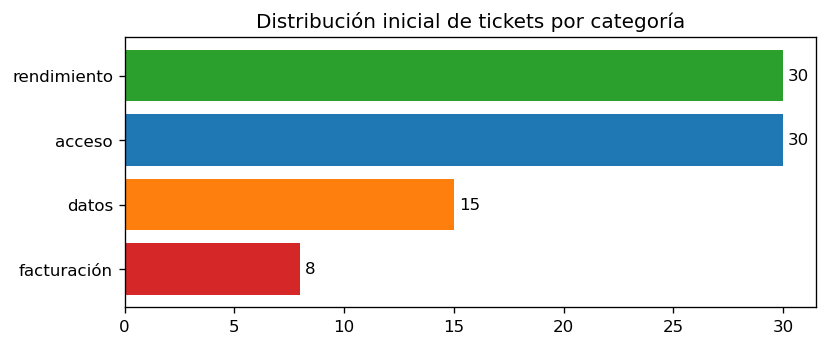

In [ ]:
gt = pd.read_csv("tickets_ground_truth.csv")
df = pd.read_csv("tickets.csv").merge(gt[["ticket_id","categoria"]], on="ticket_id")
df["es_sintetico"] = False
print(f"{len(df)} tickets cargados.")
plot_distribucion(df, "Distribucion inicial de tickets por categoria")


---
## Seccion 1 — Aumentacion sintetica
Solo 8 tickets de facturacion y 30 de datos. Antes de etiquetar hay que equilibrar las clases.
Le pedimos al LLM que genere ejemplos sinteticos.

**Lo que tienes que hacer:** escribir el prompt que usara el modelo para generar cada ticket.

### Tu turno — define el prompt de generacion

`run_generacion` llamara a `prompt_generacion(categoria, ejemplos)` para cada ticket que necesite generar.
`ejemplos` es una lista de 2 tickets reales de esa categoria.
Tú defines que instrucciones recibe el modelo.

In [ ]:
def prompt_generacion(categoria, ejemplos):
    """
    Devuelve (sistema, prompt) para generar un ticket de la categoria dada.
    """
    ejemplos_str = "\n".join(f"Ejemplo {i+1}: {e['texto'][:200]}"
                             for i, e in enumerate(ejemplos))

    # Descomenta UNA opcion:
    # sistema = "Eres un generador de tickets de soporte tecnico realistas en espanol."
    # sistema = "Generas mensajes de usuarios con problemas tecnicos. Parecen escritos por personas reales."
    # sistema = "Eres un empleado de empresa que escribe al soporte tecnico. Mensajes breves y directos."
    sistema = "TODO"  # <- borra esta linea cuando descomentes una de arriba

    prompt = (
        f"Genera un ticket de soporte para la categoria '{categoria}'.\n\n"
        f"Ejemplos reales:\n{ejemplos_str}\n\n"
        "Requisitos:\n"
        # Descomenta UNA opcion de longitud:
        # "- Entre 20 y 120 palabras\n"
        # "- Maximo 3 frases\n"
        # "- Entre 30 y 80 palabras. Solo prosa, sin listas.\n"
        # Descomenta UNA opcion de tono:
        # "- Tono variado: puede ser formal o informal\n"
        # "- A veces urgente, a veces tranquilo. Evita siempre el mismo registro.\n"
        # "- Mezcla estilos: desde muy tecnico hasta coloquial. Sin emojis.\n"
        "- Sin ticket_id ni metadatos\n\n"
        "Responde UNICAMENTE con este JSON, sin texto adicional:\n"
        '{"texto": "el texto del ticket", "categoria": "' + categoria + '"}'
    )
    return sistema, prompt

# Comprueba el prompt antes de lanzar el batch
cat_test = "facturacion"
ej_test = df[df["categoria"] == "facturaci\u00f3n"][["texto"]].to_dict("records")[:2]
_, prompt_test = prompt_generacion("facturaci\u00f3n", ej_test)
print("--- PROMPT QUE VERA EL MODELO ---")
print(prompt_test)


### Ejecuta — genera el batch y compara

Si los 3 tickets de prueba tienen buen aspecto, la celda completa el dataset hasta ~50 por categoria.

In [ ]:
# Prueba visual: 3 tickets antes del batch completo
# Si el JSON no llega limpio o el estilo no se parece a los reales, ajusta el TODO de arriba
print("=== 3 TICKETS DE PRUEBA ===\n")
ej = df[df["categoria"] == "facturación"][["texto"]].to_dict("records")[:2]
for i in range(3):
    s, p = prompt_generacion("facturación", ej)
    print(f"[{i+1}] {llamar_modelo(p, system=s)[:300]}\n")

# Genera el batch completo
conteo_antes = df["categoria"].value_counts().to_dict()
df = run_generacion(df, prompt_generacion, objetivo=25)
conteo_despues = df["categoria"].value_counts().to_dict()

plot_aumentacion(conteo_antes, conteo_despues)

# Diversidad lexica: son los sinteticos suficientemente variados?
print(f"{'Categoria':<15} {'Real':>8} {'Sintetico':>11}")
print("-"*37)
for cat in sorted(df["categoria"].unique()):
    r = diversidad_lexica(df[(df["categoria"]==cat) & ~df["es_sintetico"]]["texto"])
    s = diversidad_lexica(df[(df["categoria"]==cat) &  df["es_sintetico"]]["texto"])
    print(f"{cat:<15} {r:>8.3f} {s if s else '-':>11}")

# Si los sinteticos tienen menor diversidad, el modelo repite patrones de lenguaje.
# Eso puede hacer que el clasificador aprenda "lenguaje de IA" en vez de problemas reales.
# TODO: cambiarias algo en el prompt para aumentar la variedad?
# Respuesta:

guardar(df, 1)


---
## Seccion 2 — Etiquetado zero-shot
El dataset esta equilibrado pero sin etiquetas predichas. El modelo tiene que clasificar
cada ticket en una de las 4 categorias sin ejemplos de entrenamiento.

**Lo que tienes que hacer:** escribir el prompt de clasificacion y, tras ver los resultados,
mejorarlo para la categoria con peor F1.

### Tu turno — define el prompt de clasificacion

`run_etiquetado` llamara a `prompt_clasificacion(texto)` para cada ticket.
El output del modelo debe ser **una sola palabra** (la etiqueta).

In [ ]:
def prompt_clasificacion(texto_ticket):
    """
    Devuelve (sistema, prompt) para clasificar un ticket en una de las 4 categorias.
    El output del modelo debe ser UNA sola palabra.
    """
    # Descomenta UNA opcion:
    # sistema = "Eres un sistema de clasificacion de tickets de soporte tecnico."
    # sistema = "Clasificas mensajes de usuarios en categorias de soporte. Respuestas de una sola palabra."
    # sistema = "Eres un clasificador automatico. Produces etiquetas, nunca explicaciones."
    sistema = "TODO"  # <- borra esta linea cuando descomentes una de arriba

    prompt = (
        "Clasifica el siguiente ticket en UNA de estas categorias:\n"
        "- acceso: login, contrasenas, permisos, autenticacion\n"
        "- facturacion: pagos, facturas, suscripciones, cobros\n"
        "- rendimiento: lentitud, timeouts, cuelgues, alta latencia\n"
        "- datos: exportaciones, importaciones, perdida de datos, inconsistencias\n"
        "- no_clasificable: si no encaja claramente en ninguna\n\n"
        f"Ticket:\n\"{texto_ticket}\"\n\n"
        # Descomenta UNA opcion:
        # "Responde unicamente con la etiqueta en minusculas, sin explicacion ni puntuacion."
        # "Una sola palabra. Sin puntos, sin mayusculas, sin texto extra."
        # "Etiqueta unicamente. Si escribes mas de una palabra, la respuesta es invalida."
    )
    return sistema, prompt

# Prueba con 5 tickets antes del batch: el formato debe ser limpio (una palabra)
print("=== PRUEBA CON 5 TICKETS ===\n")
for _, row in df[~df["es_sintetico"]].sample(5, random_state=42).iterrows():
    s, p = prompt_clasificacion(row["texto"])
    raw = llamar_modelo(p, system=s)
    tok = raw.strip().lower().split()
    etq = tok[0].rstrip(".,;") if tok else "no_clasificable"
    etq = etq if etq in ETIQUETAS_VALIDAS else "no_clasificable"
    print(f"  RAW: {raw!r:<35}  PARSED: {etq:<16}  REAL: {row['categoria']}")

# Si el modelo devuelve frases en vez de una sola palabra, ajusta el TODO 2.


### Ejecuta — etiqueta el batch y evalua

In [ ]:
# Los sinteticos ya tienen categoria conocida: no hace falta que el LLM los etiquete.
# Solo procesamos los originales y copiamos la categoria en los sinteticos.
df_originales = run_etiquetado(df[~df["es_sintetico"]].copy(), prompt_clasificacion)
df.loc[~df["es_sintetico"], "categoria_predicha"] = df_originales["categoria_predicha"].values
df.loc[ df["es_sintetico"], "categoria_predicha"] = df.loc[df["es_sintetico"], "categoria"]

# Reveal: accuracy y matriz de confusion sobre los tickets originales
df_eval = reveal_accuracy(df)

# Inspeccion de errores: son ambiguos o errores claros del modelo?
errores = df_eval[df_eval["categoria_predicha"] != df_eval["real"]]
print(f"\nTickets mal etiquetados: {len(errores)}\n")
for _, row in errores.head(8).iterrows():
    print(f"  ID {row['ticket_id']} | real: {row['real']:<14} pred: {row['categoria_predicha']}")
    print(f"  {row['texto'][:120]}")
    print()

# Tu observacion (anota en el comentario):
guardar(df, 2)


---
## Seccion 3 — Resumen ejecutivo
El CTO tiene 5 minutos. 160 tickets no es una opcion: necesita un parrafo por categoria.

**Lo que tienes que hacer:** definir el prompt de resumen y responder dos preguntas de reflexion.

### Tu turno — define el prompt de resumen por categoria

`run_resumenes` llamara a `prompt_resumen(categoria, bloque_texto)` para cada categoria.
El `bloque_texto` ya viene truncado a 2000 chars (el setup lo hace automaticamente).

In [ ]:
# Contexto: el ticket mas largo — esto es lo que el CTO tendria que leer
ticket_largo = df.loc[df["texto"].str.len().idxmax()]
print(f"Ticket {ticket_largo['ticket_id']} | {len(ticket_largo['texto'])} chars\n")
print(ticket_largo["texto"])
print("\n=== RESUMEN UNA LINEA ===")
print(llamar_modelo(
    f"Resume en UNA frase de maximo 20 palabras:\n\n{ticket_largo['texto']}",
    system="Eres un asistente de soporte. Resumenes concisos."
))


In [ ]:
def prompt_resumen(categoria, bloque_texto):
    """
    Devuelve (sistema, prompt) para generar un parrafo ejecutivo de la categoria.
    bloque_texto: concatenacion de hasta 2000 chars de tickets de esa categoria.
    """
    # Descomenta UNA opcion:
    # sistema = "Eres un analista de soporte. Escribes informes ejecutivos claros y directos."
    # sistema = "Eres un director de soporte. Resumes problemas para el CTO en lenguaje no tecnico."
    # sistema = "Sintetizas tickets de soporte en parrafos ejecutivos. Conciso y orientado a decisiones."
    sistema = "TODO"  # <- borra esta linea cuando descomentes una de arriba

    prompt = (
        f"Tickets de soporte de la categoria '{categoria}':\n\n"
        f"{bloque_texto}\n\n"
        # Descomenta UNA opcion:
        # "Escribe UN parrafo (3-4 frases) con los problemas principales, patrones comunes y nivel de urgencia. Solo prosa, sin listas."
        # "Resume en 3-4 frases: problema mas frecuente, patron detectado, y si requiere accion inmediata."
        # "Un parrafo ejecutivo: que falla, cuantos usuarios afecta, que urgencia tiene. Sin listas."
    )
    return sistema, prompt

# Prueba rapida con una categoria
cat_test = df["categoria_predicha"].value_counts().index[0]
textos_test = df[df["categoria_predicha"] == cat_test]["texto"].tolist()
bloque_test = ""
for t in textos_test:
    if len(bloque_test) + len(t) > 2000: break
    bloque_test += f"- {t}\n"
s_test, p_test = prompt_resumen(cat_test, bloque_test)
print(f"Resumen de prueba ({cat_test}):\n")
print(llamar_modelo(p_test, system=s_test))


In [ ]:
resumenes = {}
for cat in sorted(df["categoria_predicha"].unique()):
    if cat == "no_clasificable": continue
    tickets_cat = df[df["categoria_predicha"] == cat]["texto"].tolist()
    bloque, incluidos = "", 0
    for t in tickets_cat:
        if len(bloque) + len(t) > 2000: break
        bloque += f"- {t}\n"; incluidos += 1
    excluidos = len(tickets_cat) - incluidos
    if excluidos: print(f"  [{cat}] {excluidos} tickets excluidos por limite de contexto")
    s, p = prompt_resumen(cat, bloque)
    resumenes[cat] = llamar_modelo(p, system=s)
    print(f"  ✓ {cat}")

# Monta y guarda el informe
lineas = [f"# Informe Ejecutivo de Soporte — {date.today()}", "",
          f"**Tickets analizados:** {len(df[~df['es_sintetico']])}", ""]
for cat, resumen in resumenes.items():
    n = len(df[df["categoria_predicha"] == cat])
    lineas += [f"## {cat.capitalize()} ({n} tickets)", "", resumen, ""]
informe = "\n".join(lineas)
with open("informe_soporte.md", "w", encoding="utf-8") as f: f.write(informe)
print("\n✓ informe_soporte.md guardado\n")
print(informe[:600])

# TODO: que informacion desaparece en el resumen que NO deberia perderse?
# Respuesta:

# TODO: para que decision de negocio NO usarias este resumen automatico?
# Respuesta:

guardar(df, 3)


---
## Seccion 4 — Extraccion estructurada
El CTO tiene el informe. Operaciones necesita datos concretos: que producto falla mas,
cuantos tickets son urgentes, que clientes han escrito. Todo esta en el texto libre.

**Lo que tienes que hacer:** definir el prompt con la estructura JSON exacta y corregirlo
para que no invente nombres de clientes.

### Tu turno — define el prompt de extraccion

`run_extraccion` llamara a `prompt_extraccion(texto)`.
El output del modelo debe ser **solo JSON valido** con los 4 campos indicados.

In [ ]:
# Plantilla JSON: usa valores concretos de ejemplo, no descripciones de campos
ESTRUCTURA_JSON = """{
  "producto": "NombreProducto o null",
  "urgencia": "alta/media/baja",
  "nombre_cliente": "NombreCliente o null",
  "accion_requerida": "Accion concreta a tomar"
}"""

# Descripcion de campos (va en el prompt, NO dentro del JSON)
DESCRIPCION_CAMPOS = (
    "Campos a rellenar:\n"
    "- producto: nombre del producto o plataforma SaaS mencionado; null si no aparece\n"
    "- urgencia: alta si impacto en produccion/multiples usuarios (ej: 'sistema caido para todos');\n"
    "           media si bloquea pero tiene alternativa (ej: 'no puedo exportar en PDF pero si CSV');\n"
    "           baja si es mejora, pregunta o problema menor (ej: 'quiero cambiar el idioma')\n"
    "- nombre_cliente: solo si el nombre aparece LITERALMENTE en el texto, null si no esta\n"
    "- accion_requerida: una frase de accion concreta para el agente\n"
)

def prompt_extraccion(texto_ticket):
    """
    Devuelve (sistema, prompt) para extraer los 4 campos como JSON.
    """
    # Descomenta UNA opcion:
    # sistema = "Eres un extractor de informacion. Devuelves UNICAMENTE JSON valido, nada mas."
    # sistema = "Extraes datos estructurados de texto. Tu output es siempre JSON puro, sin markdown."
    # sistema = "Analizas tickets y produces JSON. Nunca anades texto antes ni despues del JSON."
    sistema = "TODO"  # <- borra esta linea cuando descomentes una de arriba

    prompt = (
        "Extrae informacion del siguiente ticket. Devuelve SOLO este JSON:\n\n"
        f"{ESTRUCTURA_JSON}\n\n"
        f"{DESCRIPCION_CAMPOS}\n"
        # Descomenta UNA opcion:
        # "Responde solo con el JSON. Si el nombre no aparece tal cual en el texto: null.\n\n"
        # "Solo el JSON, nada mas. Sin ```json, sin explicaciones, sin texto adicional.\n\n"
        # "Importante: el output debe ser JSON parseable directamente. Sin comentarios.\n\n"
        f"Ticket:\n{texto_ticket}"
    )
    return sistema, prompt

# Muestra el contraste que motiva la seccion: texto libre -> JSON
ticket_ej = df[df["texto"].str.len() > 150].iloc[5]
print("=== TEXTO LIBRE ===")
print(ticket_ej["texto"])
print("\n=== JSON EXTRAIDO ===")
s, p = prompt_extraccion(ticket_ej["texto"])
print(llamar_modelo(p, system=s))


### Ejecuta — extrae el batch completo y analiza

In [ ]:
# Prueba con 3 tickets: el saneador captura texto fuera del JSON
print("=== PRUEBA SANEADOR (3 tickets) ===\n")
for _, row in df[~df["es_sintetico"]].head(3).iterrows():
    s, p = prompt_extraccion(row["texto"])
    raw = llamar_modelo(p, system=s)
    try:
        datos = sanear_json(raw)
        print(f"  ID {row['ticket_id']} OK: {datos}")
    except (json.JSONDecodeError, ValueError) as e:
        print(f"  ID {row['ticket_id']} ERROR: {e}")

# Extraccion solo sobre tickets originales (los sinteticos no aportan a la metrica de negocio)
df_orig, fallidos = run_extraccion(df[~df["es_sintetico"]].copy(), prompt_extraccion)
df = df.merge(
    df_orig[["ticket_id","producto","urgencia","nombre_cliente","accion_requerida"]],
    on="ticket_id", how="left"
)

# Texto libre -> inteligencia de negocio
print("\n=== URGENCIA ==="); print(df["urgencia"].value_counts())
print("\n=== PRODUCTOS ==="); print(df["producto"].value_counts().head(8))

plot_extraccion(df)


### Tu turno — elimina las alucinaciones de `nombre_cliente`

El modelo a veces inventa nombres aunque no aparezcan en el texto.
La celda detecta los sospechosos. Tu modificas el prompt para corregirlo.

In [ ]:
# Detecta nombres extraidos que no aparecen en el texto original
def nombre_en_texto(row):
    if pd.isna(row["nombre_cliente"]): return True
    partes = [p for p in str(row["nombre_cliente"]).lower().split() if len(p) > 3]
    return any(p in str(row["texto"]).lower() for p in partes)

sospechosos = df[~df.apply(nombre_en_texto, axis=1) & df["nombre_cliente"].notna()]
print(f"Nombres posiblemente inventados: {len(sospechosos)}")
for _, row in sospechosos.head(4).iterrows():
    print(f"  ID {row['ticket_id']}: nombre='{row['nombre_cliente']}'")
    print(f"  Texto: {row['texto'][:120]}")
    print()

# TODO: modifica prompt_extraccion (arriba) para reducir alucinaciones.
# Pista: agrega algo como "Si el nombre del cliente no aparece LITERALMENTE
# en el mensaje, devuelve null. No infieras ni inventes nombres."
# Luego relanza sobre los sospechosos:
# for _, row in sospechosos.head(5).iterrows():
#     s, p = prompt_extraccion(row["texto"])
#     print(f"ID {row['ticket_id']}: {llamar_modelo(p, system=s)[:120]}")

guardar(df, 4)


---
## Seccion 5 — Generacion de respuestas
El equipo de soporte tiene que responder los tickets urgentes antes de que acabe el dia.
Generamos borradores especializados por categoria que el agente solo revisa y envia.

**Lo que tienes que hacer:** completar los system prompts de `rendimiento` y `datos`.

### Tu turno — completa los prompts especializados

`facturacion` y `acceso` estan escritos como ejemplo.
Completa `rendimiento` (pedir logs, hora del problema) y `datos` (pedir ID de exportacion, rango de fechas).

In [ ]:
PROMPTS_POR_CATEGORIA = {
    "facturación": (
        "Eres un agente de soporte especializado en facturacion. "
        "Siempre pide numero de factura o referencia de pago y metodo de pago. "
        "Se empatico: los problemas de dinero generan ansiedad. "
        "Nunca prometas reembolsos directamente, escala al equipo de facturacion."
    ),
    "acceso": (
        "Eres un agente de soporte especializado en accesos. "
        "Pide el email con el que intenta acceder y el mensaje de error exacto. "
        "Nunca pidas la contrasena. "
        "Si el problema es de 2FA ofrece el proceso de recuperacion de cuenta."
    ),
    "rendimiento": (
        # Descomenta UN bloque y borra "TODO" de abajo:

        # "Eres un agente de soporte especializado en rendimiento y latencia. "
        # "Pide siempre: logs de consola del navegador (F12), hora aproximada del problema, "
        # "si es reproducible y con que frecuencia."

        # "Diagnosticas problemas de rendimiento. Solicita: hora exacta del error, "
        # "si otros usuarios lo reportan, y si es constante o intermitente. "
        # "Indica como abrir la consola: F12 > pestana Consola."

        # "Soporte de rendimiento: pide logs del navegador o sistema, "
        # "navegador y SO del usuario, y si el problema ocurre en todos los dispositivos."

        "TODO"  # <- borra esta linea cuando descomentes un bloque de arriba
    ),
    "datos": (
        # Descomenta UN bloque y borra "TODO" de abajo:

        # "Eres un agente de soporte especializado en datos. "
        # "Pide: ID de exportacion o importacion, rango de fechas afectado, formato del archivo. "
        # "No confirmes perdida de datos sin investigar primero."

        # "Gestionas incidencias de datos. Necesitas: tipo de operacion "
        # "(exportacion/importacion/sincronizacion), fechas afectadas y formato del fichero. "
        # "Nunca confirmes que los datos se perdieron definitivamente."

        # "Soporte de datos: solicita el ID de la operacion fallida, el intervalo de fechas "
        # "afectado y el formato del fichero. Si hay posible perdida, "
        # "escala a segundo nivel antes de confirmar nada al cliente."

        "TODO"  # <- borra esta linea cuando descomentes un bloque de arriba
    ),
}


### Ejecuta — genera borradores para urgentes y exporta

In [ ]:
df_urgentes = df[df["urgencia"] == "alta"].head(10).copy()
print(f"Tickets urgentes (muestra de 10 para el lab): {len(df_urgentes)}")

df_urgentes["borrador_respuesta"] = run_borradores(df_urgentes, PROMPTS_POR_CATEGORIA)

# Vista previa de los 3 primeros
for _, row in df_urgentes.head(3).iterrows():
    cat = row.get("categoria_predicha","?")
    print(f"\n[{cat.upper()}] Ticket {row['ticket_id']}")
    print(f"  TICKET  : {row['texto'][:100]}...")
    print(f"  BORRADOR: {row['borrador_respuesta'][:200]}...")

# Exporta
df["borrador_respuesta"] = None
df.loc[df_urgentes.index, "borrador_respuesta"] = df_urgentes["borrador_respuesta"].values
cols = ["ticket_id","categoria_predicha","urgencia","texto","borrador_respuesta"]
df_final = df[df["borrador_respuesta"].notna()][cols]
df_final.to_csv("tickets_con_borradores.csv", index=False)
print(f"\n✓ tickets_con_borradores.csv — {len(df_final)} tickets")
guardar(df, 4)


---
## Metricas del pipeline

Calcula los indicadores clave de cada seccion y muestra cuales han superado el umbral del 75%.

In [ ]:
import matplotlib.patches as mpatches

# ── S1 ────────────────────────────────────────────────────────────────────────
n_sinteticos = df["es_sintetico"].sum()
n_originales = (~df["es_sintetico"]).sum()
cats_ok = sum(1 for c in ["facturación","datos"] if (df["categoria"]==c).sum() >= 25)

# ── S2 ────────────────────────────────────────────────────────────────────────
orig       = df[~df["es_sintetico"]].copy()
ev         = orig[orig["categoria_predicha"] != "no_clasificable"]
acc_s2     = accuracy_score(ev["categoria"], ev["categoria_predicha"]) if len(ev) else 0
cobertura_s2 = len(ev) / len(orig) if len(orig) else 0

# ── S4 ────────────────────────────────────────────────────────────────────────
n_extraidos  = df[~df["es_sintetico"] & df["urgencia"].notna()].shape[0]
exito_s4     = n_extraidos / n_originales if n_originales else 0

def _nombre_ok(row):
    if pd.isna(row["nombre_cliente"]): return True
    partes = [p for p in str(row["nombre_cliente"]).lower().split() if len(p) > 3]
    return any(p in str(row["texto"]).lower() for p in partes)

df_nombres   = df[df["nombre_cliente"].notna() & ~df["es_sintetico"]]
precision_nc = df_nombres.apply(_nombre_ok, axis=1).mean() if len(df_nombres) else 1.0

# ── S5 ────────────────────────────────────────────────────────────────────────
n_urgentes   = (df["urgencia"] == "alta").sum()
n_borradores = df["borrador_respuesta"].notna().sum()
cobertura_s5 = n_borradores / n_urgentes if n_urgentes else 0

# ── Tabla ──────────────────────────────────────────────────────────────────────
print("=" * 58)
print("  METRICAS DEL PIPELINE")
print("=" * 58)
print(f"  S1  Tickets sinteticos generados:  {n_sinteticos:>4} ({n_sinteticos/(n_originales or 1):.0%} de originales)")
print(f"  S1  Categorias rebalanceadas:       {cats_ok}/2")
print(f"  S2  Accuracy zero-shot:             {acc_s2:.1%}  ({len(ev)} tickets clasificados)")
print(f"  S2  Cobertura (excl. no_clasif.):  {cobertura_s2:.1%}")
print(f"  S4  Extraccion JSON correcta:       {exito_s4:.1%}  ({n_extraidos}/{n_originales})")
print(f"  S4  Precision nombre_cliente:       {precision_nc:.1%}")
print(f"  S5  Borradores generados:           {n_borradores}/{n_urgentes} urgentes")
print("=" * 58)

# ── Grafico ────────────────────────────────────────────────────────────────────
metricas = [
    ("S2  Accuracy\nzero-shot",      acc_s2),
    ("S2  Cobertura\n(sin NC)",       cobertura_s2),
    ("S4  Extraccion\nJSON ok",       exito_s4),
    ("S4  Nombres\nsin inventar",     precision_nc),
    ("S5  Borradores\nurgentes",      cobertura_s5),
]

fig, ax = plt.subplots(figsize=(7, 4))
labels = [m[0] for m in metricas]
vals   = [min(m[1], 1.0) for m in metricas]
colors = ["#2ca02c" if v >= 0.75 else "#ff7f0e" if v >= 0.5 else "#d62728" for v in vals]

bars = ax.barh(labels[::-1], vals[::-1], color=colors[::-1], alpha=0.85, height=0.5)
for bar, v in zip(bars, vals[::-1]):
    ax.text(min(v, 1.0) + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:.0%}", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 1.18)
ax.set_xlabel("Porcentaje de exito")
ax.set_title("Metricas del pipeline — resumen de la sesion", fontsize=12)
ax.axvline(0.75, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(0.76, -0.55, "objetivo 75%", fontsize=8, color="gray")
patches = [mpatches.Patch(color=c, label=l) for c, l in
           [("#2ca02c", "≥ 75%"), ("#ff7f0e", "50-74%"), ("#d62728", "< 50%")]]
ax.legend(handles=patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


---
## El pipeline completo

| Columna | Origen | Seccion |
|---------|--------|---------|
| `ticket_id`, `texto` | `tickets.csv` | — |
| `categoria` | ground truth (merge inicial) | — |
| `es_sintetico` | LLM generacion | S1 |
| `categoria_predicha` | LLM clasificacion | S2 |
| `producto`, `urgencia`, `nombre_cliente`, `accion_requerida` | LLM extraccion | S4 |
| `borrador_respuesta` | LLM generacion | S5 |

De **2 columnas** a **9** — sin GPU, sin transformers, sin modelo entrenado.

---

## Reflexion final

> **En que paso del pipeline pondrias revision humana obligatoria?**
> Piensa en: donde puede propagarse un error silenciosamente?
> Donde el coste de equivocarse es mayor (economico, legal, reputacional)?

In [ ]:
# TODO: responde a la reflexion final

# El paso donde pondria revision humana obligatoria:
# Porque:
# El coste de un error sin revision seria:

print("Archivos generados durante la sesion:")
for f in ["checkpoint_s1.csv","checkpoint_s2.csv","checkpoint_s3.csv",
          "checkpoint_s4.csv","informe_soporte.md","tickets_con_borradores.csv"]:
    print(f"  {'✓' if os.path.exists(f) else '✗'}  {f}")
